In [52]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import pandas as pd
import glob
import os
import xarray as xr
import rasterio as rio
from rasterio.mask import mask
from shapely.geometry import mapping
import geopandas as gpd
from pyproj import Proj

In [53]:
utm12Proj = Proj("+proj=utm +zone=12 +hemisphere='N' +ellps=WGS84 +datum=WGS84 +units=m +no_defs") # UTM Zone 12N

# Process the field data from 2020 Grand Mesa campaign

In [54]:
folder = '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/field_data/'
os.listdir(folder)

['GrandMesa_boundary_UTM.prj',
 'Lidar_bcal_processed',
 'SNEX20_GM_SWE_SD_Lidar-GPR_20200201_v01.0.csv',
 'SNEX20_GM_SWE_SD_SnowDensity_20200201_v01.0.tif',
 '.DS_Store',
 'depth',
 'SNEX20_GM_Lidar_SD_20200201_20200202_v01.0.tif',
 'SnowEx20_SnowPits_GMIOP_Summary_Environment_2020_v01.csv',
 'SnowEx2020_SnowDepths_COGM_alldepths_v01_handmeasurements.csv',
 'density',
 'snowmobile_roads.prj',
 'GrandMesa_WGS.prj',
 'GrandMesa_boundary_UTM.shp',
 'GM2020_fieldmap.qgz',
 'GrandMesa_WGS.dbf',
 'snowmobile_roads.dbf',
 'SNEX20_GIS_REF_GM_v01',
 'GrandMesa_boundary_UTM.shx',
 'GrandMesa_boundary_UTM.qmd',
 'Tate_results',
 'SNEX20_GM_SWE_SD_SWE_20200201_v01.0.tif',
 'SnowEx20_SnowPits_GMIOP_Summary_SWE_2020_v01.csv',
 'meterology',
 'SNEX20_GM_Lidar_SDsubset_20200201_20200202_v01.0.tif',
 'snowmobile_roads.shx',
 'GrandMesa_WGS.qmd',
 'GrandMesa_WGS.shx',
 'snowmobile_roads.cpg',
 'snowmobile_roads.shp',
 'GrandMesa_boundary_UTM.dbf',
 'GrandMesa_WGS.cpg',
 'GrandMesa_WGS.shp']

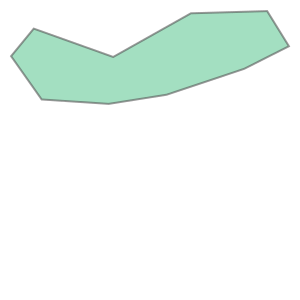

In [55]:
# read site shapefile with geopandas
site_gdf = gpd.read_file(folder+'GrandMesa_boundary_UTM.shp')
geoms = site_gdf.geometry.values
geom = geoms[0]
# site_gdf
geom

## 1) Calculate velocity from density

In [56]:
# list density files
os.listdir(folder+'density/')

['SNEX20_GM_SWE_SD_Lidar-GPR_20200201_v01.0.csv',
 'SNEX20_GM_SWE_SD_SnowDensity_20200201_v01.0.tif',
 'SnowEx20_SnowPits_GMIOP_Summary_SWE_2020_v01.csv']

(3500, 4501)


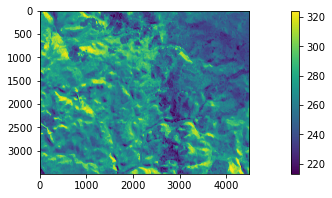

In [57]:
# read in density raster 
density_snex_r = rio.open(folder+'density/SNEX20_GM_SWE_SD_SnowDensity_20200201_v01.0.tif')
density_snex = density_snex_r.read(1)
density_snex[density_snex < 0] = np.NaN # all negative numbers are not real values 
print(density_snex.shape)

# # crop to site shapefile - unnecessary, it's a small region fully inside site bounds
# out_image, out_transform = mask(density_snex_r, [mapping(geom)], crop=True)
# crop_array = out_image[0,:,:]
# crop_array[crop_array < -1e3] = np.NaN

# plot
fig, ax = plt.subplots(figsize=(15,3)); 
plt.imshow(density_snex)
# plt.imshow(crop_array)
plt.colorbar(); ax.set_facecolor('black'); plt.show()

In [58]:
# read in density CSV
density_df = pd.read_csv(folder+'density/SNEX20_GM_SWE_SD_Lidar-GPR_20200201_v01.0.csv')
measured_densities = density_df['Density (kg/m3)']
# density_df = pd.read_csv(folder+'density/SnowEx20_SnowPits_GMIOP_Summary_SWE_2020_v01.csv')
# measured_densities = density_df['Density Mean (kg/m^3)']
density_df.head()

,Index,X (WGS84 UTM 12N),Y (WGS84 UTM 12N),TWT (ns),Depth (cm),Density (kg/m3),SWE (mm),Velocity (m/ns),Permittivity
0,1167683,741832.069571,4.322818e+06,6.3,77.998048,240.714051,187.752261,0.249129,1.450087
1,1167684,741832.069571,4.322817e+06,6.0,74.189454,242.537355,179.937140,0.248810,1.453802
2,1167685,741832.069571,4.322816e+06,7.2,89.008790,242.836446,216.145783,0.248758,1.454412
3,1167686,741832.069571,4.322815e+06,7.0,86.518556,243.131157,210.353566,0.248707,1.455013
4,1167687,741832.069571,4.322814e+06,5.5,67.890626,244.996712,166.329802,0.248382,1.458821


In [59]:
# calculate the density 
calculated_density = np.array(measured_densities) # CSV file
print(np.nanmean(calculated_density))
# calculated_density = density_snex.flatten() # raster data

270.69690861828343


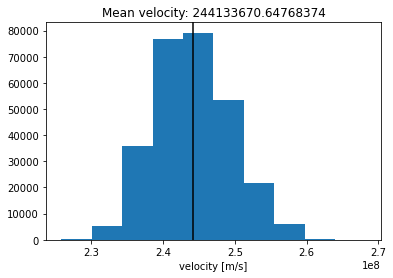

In [167]:
# from density, calculate the radar wave velocity using e_snowdry equation
calculated_velocity = np.sqrt((3e8**2)/(1+(1.7*calculated_density/1000) + (0.7*(calculated_density/1000)**2)))

# plot and show mean
plt.hist(calculated_velocity,bins=10)
plt.title('Mean velocity: '+str(np.nanmean(calculated_velocity)));
plt.axvline(x=np.nanmean(calculated_velocity),color='k')
plt.xlabel('velocity [m/s]')
plt.show()

## 2) Compare lidar depth maps

In [168]:
# list depth files
os.listdir(folder+'depth/')

['SNEX20_GM_Lidar_SD_20200201_20200202_v01.0.tif.aux.xml',
 'SNEX20_GM_SWE_SD_Lidar-GPR_20200201_v01.0.csv',
 'SNEX20_GM_Lidar_SD_20200201_20200202_v01.0_UTM12.tif.aux.xml',
 'SNEX20_GM_Lidar_SD_20200201_20200202_v01.0.tif',
 'SnwDpth_Grnd_Asp_Slp_CPC_CHM_FHD512.tif',
 'SnowEx2020_SnowDepths_COGM_alldepths_v01_handmeasurements.csv',
 'SnowEx20_SnowPits_GMIOP_Summary_SWE_2020_v01.csv',
 'SNEX20_GM_Lidar_SD_20200201_20200202_v01.0_UTM12.tif',
 'SnwDpth_Grnd_Asp_Slp_CPC_CHM_FHD512.tif.aux.xml']

(3501, 17004)


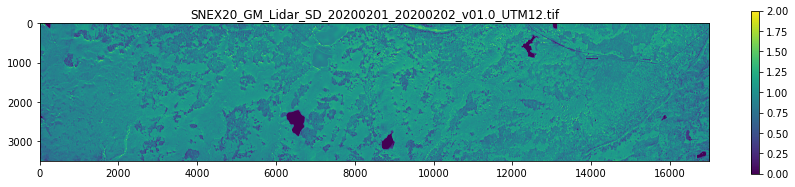

In [98]:
lidar_snex_r = rio.open(folder+'depth/SNEX20_GM_Lidar_SD_20200201_20200202_v01.0_UTM12.tif')
lidar_snex = lidar_snex_r.read(1)
lidar_snex[lidar_snex < 0] = np.NaN # all negative numbers are not real values 
print(lidar_snex.shape)
fig, ax = plt.subplots(figsize=(15,3)); plt.imshow(lidar_snex,vmin=0,vmax=2); # plot
plt.title('SNEX20_GM_Lidar_SD_20200201_20200202_v01.0_UTM12.tif')

grid_X = np.arange(lidar_snex_r.bounds.left+0.5, lidar_snex_r.bounds.right,0.9997369)
grid_Y = np.arange(lidar_snex_r.bounds.top-0.5, lidar_snex_r.bounds.bottom,-0.9997369)

plt.colorbar(); ax.set_facecolor('black'); plt.show()

In [170]:
lidar_snex_crop = lidar_snex[:3500,4:]
lidar_snex_crop.shape

(3500, 17000)

Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


(3500, 17000)


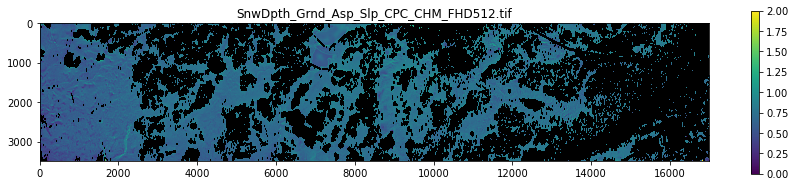

In [97]:
lidar_bcal_r = rio.open(folder+'depth/SnwDpth_Grnd_Asp_Slp_CPC_CHM_FHD512.tif')
lidar_bcal = lidar_bcal_r.read(1) # first band is snow depth
lidar_bcal[lidar_bcal < 0] = np.NaN
print(lidar_bcal.shape)

grid_X = np.arange(lidar_bcal_r.bounds.left+0.5, lidar_bcal_r.bounds.right,0.9997369)
grid_Y = np.arange(lidar_bcal_r.bounds.top-0.5,lidar_bcal_r.bounds.bottom,-0.9997369)

fig, ax = plt.subplots(figsize=(15,3)); plt.imshow(lidar_bcal,vmin=0,vmax=2); 
plt.title('SnwDpth_Grnd_Asp_Slp_CPC_CHM_FHD512.tif');
plt.colorbar(); ax.set_facecolor('black'); plt.show()

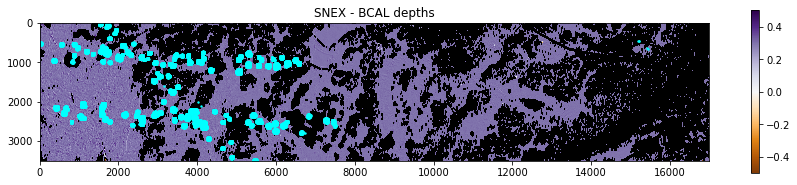

In [172]:
fig, ax = plt.subplots(figsize=(15,3)); 
plt.imshow(lidar_snex_crop - lidar_bcal, cmap='PuOr', vmin=-0.5, vmax=0.5); plt.colorbar()
plt.title('SNEX - BCAL depths'); 
plt.scatter(x_idxs,y_idxs,color='cyan',s=2); 
plt.xlim(0,lidar_bcal.shape[1]); plt.ylim(lidar_bcal.shape[0],0)
ax.set_facecolor('black'); plt.show()

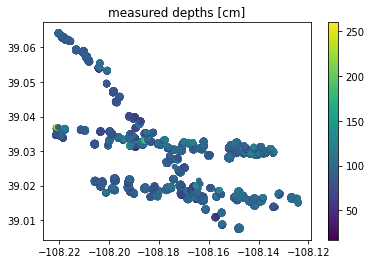

In [173]:
# grab other depth data
depth_df = pd.read_csv(folder+'depth/SnowEx2020_SnowDepths_COGM_alldepths_v01_handmeasurements.csv')
plt.scatter(depth_df.Longitude,depth_df.Latitude,c=depth_df['Depth (cm)'],s=25)
depth_df = depth_df[depth_df.Longitude < -108.10]
plt.title('measured depths [cm]')
plt.colorbar(); plt.show()

In [104]:
# write code to compare pt & gridded data - rasterio.show()
snex_depths = []; bcal_depths = []; measured_depths = []; x_idxs = []; y_idxs = []
for idx, row in depth_df.iterrows():
    [utmx, utmy] = utm12Proj(row.Longitude, row.Latitude)
    
    if utmx >= lidar_bcal_r.bounds.left and utmx <= lidar_bcal_r.bounds.right:
        if utmy >= lidar_bcal_r.bounds.bottom and utmy <= lidar_bcal_r.bounds.top:
            x_mindist = np.min(np.abs(grid_X-utmx)); y_mindist = np.min(np.abs(grid_Y-utmy))
            if x_mindist >= 0.5 or y_mindist >= 0.5: # if outside of grid cell (> 0.5 m from the grid center)
#                 lidar_depth = np.NaN # failsafe!
                print('out of bounds.')
            else: # if within grid cell, grab the lidar snow depth
                x_idx = np.argmin(np.abs(grid_X-utmx)); y_idx = np.argmin(np.abs(grid_Y-utmy))
                snex_depths.append(lidar_snex_crop[y_idx-1,x_idx-1]) # grab from raster
                bcal_depths.append(lidar_bcal[y_idx-1, x_idx-1]) # grab from raster
                measured_depths.append(float(row['Depth (cm)']))
                y_idxs.append(y_idx-1); x_idxs.append(x_idx-1)

In [ ]:
a=0.3; plotlim = 200; fs = 13
plt.figure(figsize=(5,5))
plt.scatter(measured_depths, np.array(snex_depths)*100, label='SNEX depths', alpha=a)
plt.scatter(measured_depths, np.array(bcal_depths)*100, label='BCAL depths', alpha=a)
plt.plot([0, plotlim],[0,plotlim], 'k-')
plt.xlabel('measured depth [cm]',fontsize=fs); plt.ylabel('remotely sensed depth [cm]',fontsize=fs)
plt.legend(fontsize=fs); plt.gca().set_aspect('equal'); plt.xlim(0,plotlim); plt.ylim(0,plotlim)
plt.tick_params(labelsize=fs)
plt.show()

## Work with radar data

In [7]:
import glob
radaroutpath = '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/final_radar_picks/'
FMCW_processed = '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed/'
FMCW_results = '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_wavelet_results/'

In [9]:
# date = '20200129'
# transect_list = ['1S1_spiral','2S2_MRpit','2S2_spiral','2S5','3S5_MRpit','6S19_spiral_part2',
#                  'GM20200129_returnbase','gm29Jan2020_start']

In [8]:
# # grab all CSV files from within the wavelet results / figures folders for all FMCW_results folders
# # that start with the transect name
# date_dfs = []
# for transect in transect_list:
#     print(transect)
#     # for each transect, concat dfs
#     transect_dfs = []
#     for folder in os.listdir(FMCW_results):
#         if folder.startswith(transect):
#             csv_files = glob.glob(FMCW_results+folder+'/figures/*.csv')
#             print(csv_files)
            
#             df = pd.read_csv(csv_files[0])
#             df = df.drop(columns='Unnamed: 0')
#             transect_dfs.append(df)
                   
#     transect_df = pd.concat(transect_dfs) # concat and add columns
#     transect_df['transect_name'] = transect
#     transect_df['collection_date'] = date
#     date_dfs.append(transect_df)
# date_df = pd.concat(date_dfs) # concat all for date
# date_df.to_csv(radaroutpath+'GM2020_rdpicks_'+date+'.csv')# export
# date_df

In [178]:
# concatenate all radar dfs
df_files = glob.glob(radaroutpath+'GM2020*.csv')
df_files.sort()
dfs = []
for file in df_files:
    df = pd.read_csv(file);
    dfs.append(df)
all_df = pd.concat(dfs)
all_df = all_df.drop(columns='Unnamed: 0')

In [186]:
all_df.to_csv(radaroutpath+'GM2020_rdpicks_all.csv')

# Compare radar vs lidar for all sites

In [91]:
all_df = pd.read_csv(radaroutpath+'GM2020_rdpicks_all_roadadjusted.csv')
all_df

,Unnamed: 0,index,Unnamed: 0.1,x,y,Isurf,Iground,rd_xidx,TWT_surf,TWT_ground,rd_id,radar_depth_cm,lidar_depth,transect_name,collection_date,Unnamed: 0.1.1,Unnamed: 0.1.1.1
0,0,0,0,741911.781848,4.324354e+06,416.0,1168.0,141.0,4.225000e-09,1.186250e-08,rd01,85.196406,86.274414,1N6_5N10,20200128,NaN,NaN
1,1,1,1,741911.781848,4.324354e+06,416.0,1170.0,142.0,4.225000e-09,1.188281e-08,rd01,85.444219,86.274414,1N6_5N10,20200128,NaN,NaN
2,2,2,2,741911.781848,4.324354e+06,416.0,1171.0,143.0,4.225000e-09,1.189297e-08,rd01,85.568125,86.274414,1N6_5N10,20200128,NaN,NaN
3,3,3,3,741911.801295,4.324354e+06,416.0,1172.0,144.0,4.225000e-09,1.190313e-08,rd01,85.692031,86.274414,1N6_5N10,20200128,NaN,NaN
4,4,4,4,741911.801295,4.324354e+06,416.0,1174.0,145.0,4.225000e-09,1.192344e-08,rd01,85.939844,86.274414,1N6_5N10,20200128,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4261267,4261267,6677147,1267122,750191.547345,4.322257e+06,493.0,1312.0,3011.0,5.010040e-09,1.333301e-08,rd61,91.558179,113.520500,NorthLinee2,20200212,NaN,NaN
4261268,4261268,6677148,1267123,750191.569064,4.322258e+06,492.0,1312.0,3012.0,4.999878e-09,1.333301e-08,rd61,91.682159,113.520500,NorthLinee2,20200212,NaN,NaN
4261269,4261269,6677149,1267124,750191.569064,4.322258e+06,492.0,1312.0,3013.0,4.999878e-09,1.333301e-08,rd61,91.682159,113.520500,NorthLinee2,20200212,NaN,NaN
4261270,4261270,6677150,1267125,750191.569064,4.322258e+06,492.0,1312.0,3014.0,4.999878e-09,1.333301e-08,rd61,91.682159,114.399410,NorthLinee2,20200212,NaN,NaN


In [99]:
# shifted_df = all_df
# shifted_df.x = shifted_df.x+3.0
# shifted_df

In [101]:
# shift x and y and re-extract lidar
print('extracting lidar data...')
# ADD IN RANGE OF ARM LENGTHS TO TEST
x_idxs = []; y_idxs = []; lidar_depths = []
arm_length = 1.5 # consider arm_length [meters] on radar (set to 0 if none)
for i in range(0, len(shifted_df.x)):
    x0 = shifted_df.x[i]; y0 = shifted_df.y[i]
    if i+1 < len(shifted_df):
        x1 = shifted_df.iloc[i+1].x; y1 = shifted_df.iloc[i+1].y # grab next point
        x = x1-x0; y = y1-y0 # calculate distance between points

        angle0 = np.degrees(np.arctan2(y,x)) # calculate angle between current and next point
        angle_arm = angle0 - 90 # calculate the angle to the arm, 90 degrees to the right (-90)
        if angle_arm <= -180: # reset to north direction if angle is less than -180
            angle_arm = angle_arm + 360
    # Calculate the arm location using the angle_arm
    dx = arm_length * np.cos(np.radians(angle_arm))
    dy = arm_length * np.sin(np.radians(angle_arm))
    x_arm = x0 + dx; y_arm = y0 + dy

    # 1st pass, remove them out of bounds
    if x_arm < lidar_snex_r.bounds.left or x_arm > lidar_snex_r.bounds.right:
        lidar_depth = np.NaN
    elif y_arm < lidar_snex_r.bounds.bottom or y_arm > lidar_snex_r.bounds.top:
        lidar_depth = np.NaN
    else: # if in bounds, grab the nearest x and nearest y to the radar pt
        x_mindist = np.min(np.abs(grid_X-x_arm)); y_mindist = np.min(np.abs(grid_Y-y_arm))
        if x_mindist >= 0.5 or y_mindist >= 0.5: # if outside of grid cell (> 0.5 m from the grid center)
            lidar_depth = np.NaN # failsafe!
        else: # if within grid cell, grab the lidar snow depth
            x_idx = np.argmin(np.abs(grid_X-x_arm)); y_idx = np.argmin(np.abs(grid_Y-y_arm))
            lidar_depth = lidar_snex[y_idx-1,x_idx-1] # grab from raster
    lidar_depths.append(lidar_depth) # add to list
shifted_df['lidar_depth'] = lidar_depths # add into dataframe
shifted_df = shifted_df[shifted_df.lidar_depth > 0] # only keep > 0 depth

extracting lidar data...


In [102]:
all_df = shifted_df

In [109]:
all_df.lidar_depth = all_df.lidar_depth*100

/Users/jukesliu/opt/anaconda3/envs/newautoriftenv/lib/python3.9/site-packages/pandas/core/generic.py:5507: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[name] = value


In [110]:
from scipy.interpolate import interp1d
from sklearn.metrics import r2_score, mean_squared_error 

def weighted_avg(xpoints,ypoints,values,xarray,yarray,winsize):
    import numpy as np
    # calculated weighted average of the values at coordinates xarray,yarray within an N-meter radius of x0,y0
    # INPUTS:
    # xpoints = x-coordinate of the points at center of the window [m]
    # ypoints = y-coordinate of the point at center of the window [m]
    # values = values to average
    # xarray = x-coordinates of the values [m]
    # yarray = y-coordinates fo the values [m]
    # winsize = N-meter window (radius of circular window)
    # OUTPUTS:
    # mean_vals = list of weighted mean values
    # val_stds = list of std of values within each window
    
    sigma = winsize/2 
    mean_vals = []; val_stds = []
    for i in range(0, len(xpoints)):
        x0 = xpoints[i]; y0 = ypoints[i]
        
        # calculate distances to the point
        distance = euclidian_dist(x0,y0,xarray,yarray)
#         print(distance)
        weights = np.exp(-distance**2 / (2 * sigma**2))
        weighted_values = values*weights
        weighted_sum = np.nansum(weighted_values)

        if len(values) != len(weights):
            raise ValueError("Values and weights lists must have the same length.")

        sum_of_weights = np.nansum(weights)
        if sum_of_weights == 0:
#             raise ZeroDivisionError("Sum of weights cannot be zero.")
            mean_vals.append(np.NaN); val_stds.append(np.NaN) # add NaNs to lists
            continue
        mean_val = weighted_sum / sum_of_weights
        val_std = np.nanstd(weighted_values)
        
        if mean_val < -1000: # mean_val should never be this negative, this is to filter -inf division
            mean_val = np.NaN
        if val_std < -1000:
            val_std = np.NaN

        # add to lists
        mean_vals.append(mean_val); val_stds.append(val_std)
        
    return mean_vals, val_stds

def euclidian_dist(x1,y1,x2,y2):
    import numpy as np
    dist = np.sqrt((x2-x1)**2 + (y2-y1)**2)
    return dist

In [111]:
all_filtered_noNans = all_df.dropna(subset=['lidar_depth']) # prior to 1 to 1 plot, drop 0 lidars
all_filtered_noNans.reset_index(inplace=True)

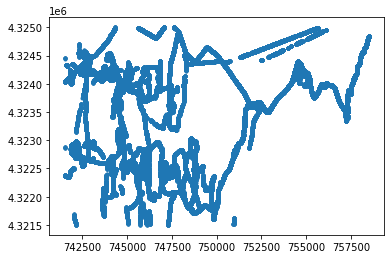

140162 4249295


In [112]:
# grab only x,y every 1 m and remove repeats
evenly_spaced_df = all_filtered_noNans.copy() # create a copy
evenly_spaced_df['x_rounded'] = np.round(evenly_spaced_df.x)
evenly_spaced_df['y_rounded'] = np.round(evenly_spaced_df.y)
evenly_spaced_df.drop_duplicates(subset=['x_rounded','y_rounded'], keep='first', inplace=True) # drop repeats
evenly_spaced_df = evenly_spaced_df.reset_index(drop=True)
plt.plot(evenly_spaced_df.x, evenly_spaced_df.y, '.'); plt.show()
spaced_dist = range(0, len(evenly_spaced_df))
print(len(evenly_spaced_df), len(all_filtered_noNans))

In [ ]:
# window = 10 # meters
for window in [3,10,50,150]:
#     for depth_shift in [15]: - doesn't work need to subtract
#         print(window, depth_shift)
        # interpolate the radar data
        [radar_avg, radar_std] = weighted_avg(evenly_spaced_df.x, evenly_spaced_df.y,
                                              all_filtered_noNans.radar_depth_cm, 
                     all_filtered_noNans.x, all_filtered_noNans.y, window)
        # interpolate the lidar data
        [lidar_avg, lidar_std] = weighted_avg(evenly_spaced_df.x, evenly_spaced_df.y,
                                              all_filtered_noNans.lidar_depth, 
                     all_filtered_noNans.x, all_filtered_noNans.y, window)

#         radar_avg = np.array(radar_avg)+depth_shift # DEPTH SHIFT
        # RADAR DEPTHS WERE ALREADY SHIFTED

        # calculate RMSE and percent error
        RMSE = np.round(np.sqrt(np.nanmean((np.array(radar_avg) - np.array(lidar_avg))**2)),2)
        percent_err = np.round(RMSE/np.nanmean(radar_avg)*100,1)

        # plot snow depths along the transect
        fs = 14; a = 0.1; cs = 5; lw=2; ms=2; maxval = 400
        fig, (ax,ax2) = plt.subplots(1,2,figsize=(15,5))
        ax.errorbar(spaced_dist, radar_avg, yerr=radar_std, marker='.',markersize=ms,
                    color='red',linewidth=lw,label='radar',capsize=cs,alpha=a) # radar
        ax.errorbar(spaced_dist, lidar_avg, yerr=lidar_std, marker='.',markersize=ms, 
                    color='orange',linewidth=lw,label='lidar',capsize=cs,alpha=a) # lidar
        ax.legend(fontsize=fs,loc='upper left')
        ax.set_ylabel('Snow depth [cm]',fontsize=fs); ax.set_xlabel('index', fontsize=fs)
        ax.set_xlim(0,np.nanmax(spaced_dist)); ax.set_ylim(0,maxval)
        ax.set_facecolor('darkgrey'); plt.grid(); ax.tick_params(labelsize=fs)
        ax.set_title('RMSE='+str(RMSE)+' cm, '+str(percent_err)+' % error',fontsize=fs)
        
        # 1 to 1 plot
        minval=0
        ax2.plot(lidar_avg, radar_avg, 'o', alpha=a,label=window) # points
        ax2.plot([minval,maxval],[minval,maxval],'k-') # 1 to 1 line
        ax2.set_title(str(window)+' m window',fontsize=fs) # plot title
        plt.gca().set_aspect('equal'); ax2.grid(); ax2.set_facecolor('darkgrey')
        ax2.set_xlim(minval,maxval); ax2.set_ylim(minval,maxval); ax2.tick_params(labelsize=fs)
        ax2.set_xlabel('weighted avg. lidar depth [cm]', fontsize=fs)
        ax2.set_ylabel('weighted avg. radar depth [cm]', fontsize=fs)
    
        plt.tight_layout()
        plt.savefig(radaroutpath+'all_depths_comparison_roadadjusted_xshifted_'+str(window)+'m.jpg',dpi=200)
        plt.show()

# Compare field measurements to radar

In [87]:
all_df = pd.read_csv(radaroutpath+'GM2020_rdpicks_all_roadadjusted.csv')
all_df.head()

,Unnamed: 0,index,Unnamed: 0.1,x,y,Isurf,Iground,rd_xidx,TWT_surf,TWT_ground,rd_id,radar_depth_cm,lidar_depth,transect_name,collection_date,Unnamed: 0.1.1,Unnamed: 0.1.1.1
0,0,0,0,741911.781848,4.324354e+06,416.0,1168.0,141.0,4.225000e-09,1.186250e-08,rd01,85.196406,86.274414,1N6_5N10,20200128,NaN,NaN
1,1,1,1,741911.781848,4.324354e+06,416.0,1170.0,142.0,4.225000e-09,1.188281e-08,rd01,85.444219,86.274414,1N6_5N10,20200128,NaN,NaN
2,2,2,2,741911.781848,4.324354e+06,416.0,1171.0,143.0,4.225000e-09,1.189297e-08,rd01,85.568125,86.274414,1N6_5N10,20200128,NaN,NaN
3,3,3,3,741911.801295,4.324354e+06,416.0,1172.0,144.0,4.225000e-09,1.190313e-08,rd01,85.692031,86.274414,1N6_5N10,20200128,NaN,NaN
4,4,4,4,741911.801295,4.324354e+06,416.0,1174.0,145.0,4.225000e-09,1.192344e-08,rd01,85.939844,86.274414,1N6_5N10,20200128,NaN,NaN


37921


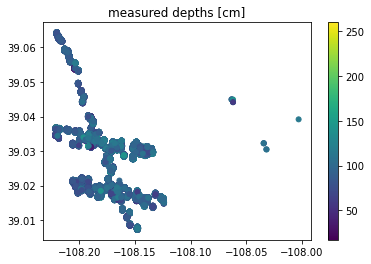

In [71]:
# grab measured depth data
depth_df = pd.read_csv(folder+'depth/SnowEx2020_SnowDepths_COGM_alldepths_v01_handmeasurements.csv')
# depth_df
print(len(depth_df))
plt.scatter(depth_df.Longitude,depth_df.Latitude,c=depth_df['Depth (cm)'],s=25)
# depth_df = depth_df[depth_df.Longitude < -108.10]
plt.title('measured depths [cm]')
plt.colorbar(); plt.show()

In [72]:
# field measurements
depth_df = depth_df.sort_values(by='Northing')
depth_df.head()

,Measurement Tool (MP = Magnaprobe; M2 = Mesa 2; PR = Pit Ruler),ID,Date (yyyymmdd),"Time (hh:mm, local, MST)",PitID,Longitude,Latitude,Easting,Northing,Depth (cm),elevation (m),equipment,Version Number
4269,MP,104270,20200129,7:06,6C37,-108.14793,39.00714,746962.04,4321439.12,85,3087.3,CRREL_B,1
4268,MP,104269,20200129,7:06,6C37,-108.14792,39.00714,746962.90,4321439.52,80,3086.9,CRREL_B,1
4270,MP,104271,20200129,7:06,6C37,-108.14795,39.00715,746960.42,4321440.18,68,3088.6,CRREL_B,1
4271,MP,104272,20200129,7:06,6C37,-108.14797,39.00715,746959.09,4321440.88,66,3089.1,CRREL_B,1
4267,MP,104268,20200129,7:06,6C37,-108.14788,39.00715,746966.32,4321441.11,97,3087.8,CRREL_B,1


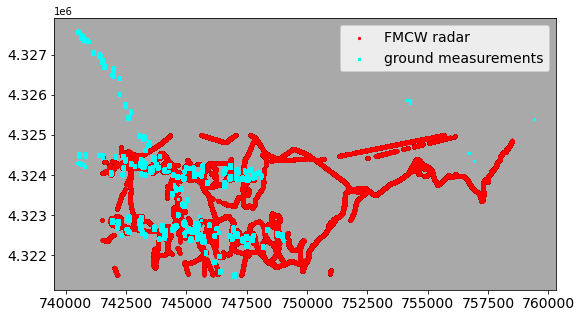

In [79]:
# plot overlap
fs = 14; a=1
fig, ax = plt.subplots(figsize=(9,5))
# plt.plot(bounds_x, bounds_y, label='site boundary')
plt.scatter(all_df.x, all_df.y, color='red', label='FMCW radar', s=5, alpha=a)
plt.scatter(depth_df.Easting,depth_df.Northing,color='cyan',label='ground measurements',
            marker='s', s=7,alpha=a)
plt.legend(fontsize=fs); plt.tick_params(labelsize=fs)
ax.set_facecolor('darkgrey'); ax.tick_params(labelsize=fs)
plt.show()

In [88]:
all_filtered_noNans = all_df.dropna(subset=['radar_depth_cm']) # prior to 1 to 1 plot, drop empty radar points
all_filtered_noNans.reset_index(inplace=True)

In [81]:
# # calculate radar average at field measurements of depth
# window = 3

# [radar_avg, radar_std] = weighted_avg(depth_df.Easting, depth_df.Northing, all_filtered_noNans.radar_depth_cm, 
#              all_filtered_noNans.x, all_filtered_noNans.y, window)
# # # interpolate the lidar data
# # [measured_avg, measured_std] = weighted_avg(x_spaced, y_spaced, depth_df['Depth (cm)'], 
# #              all_filtered_noNans.x, all_filtered_noNans.y, window)

In [90]:
shifted_df = all_filtered_noNans
shifted_df = shifted_df[shifted_df.lidar_depth > 0] # only keep > 0 depth
print('calculating r^2...')
radar_depths = np.array(shifted_df.radar_depth_cm)
lidar_depths = np.array(shifted_df.lidar_depth)
ss_res = np.nansum((lidar_depths - radar_depths)**2) # Sum of squares of residuals
ss_tot = np.nansum((lidar_depths - np.nanmean(lidar_depths))**2) # Total sum of squares
r2 = 1 - (ss_res / ss_tot)
print(r2)

calculating r^2...
-1.1782632100976391


In [ ]:
spaced_dist = range(0,len(depth_df))

In [ ]:
# calculate RMSE and percent error
RMSE = np.round(np.sqrt(np.nanmean((np.array(radar_avg) - np.array(lidar_avg))**2)),2)
percent_err = np.round(RMSE/np.nanmean(radar_avg)*100,1)

# plot snow depths along the transect
fs = 14; a = 0.1; cs = 5; lw=2; ms=2; maxval = 400
fig, (ax,ax2) = plt.subplots(1,2,figsize=(15,5))
ax.errorbar(spaced_dist, radar_avg, yerr=radar_std, marker='.',markersize=ms,
            color='red',linewidth=lw,label='radar',capsize=cs,alpha=a) # radar
ax.errorbar(spaced_dist, depth_df['Depth (cm)'], marker='.',markersize=ms, 
            color='cyan',linewidth=lw,label='measured',capsize=cs,alpha=a) # lidar
ax.legend(fontsize=fs,loc='upper left')
ax.set_ylabel('Snow depth [cm]',fontsize=fs); ax.set_xlabel('index', fontsize=fs)
ax.set_xlim(0,np.nanmax(spaced_dist)); ax.set_ylim(0,maxval)
ax.set_facecolor('darkgrey'); plt.grid(); ax.tick_params(labelsize=fs)
ax.set_title('RMSE='+str(RMSE)+' cm, '+str(percent_err)+' % error',fontsize=fs)

# 1 to 1 plot
minval=0
ax2.plot(depth_df['Depth (cm)'], radar_avg, 'o', alpha=a,label=window) # points
ax2.plot([minval,maxval],[minval,maxval],'k-') # 1 to 1 line
ax2.set_title(str(window)+' m window',fontsize=fs) # plot title
plt.gca().set_aspect('equal'); ax2.grid(); ax2.set_facecolor('darkgrey')
ax2.set_xlim(minval,maxval); ax2.set_ylim(minval,maxval); ax2.tick_params(labelsize=fs)
ax2.set_xlabel('weighted avg. lidar depth [cm]', fontsize=fs)
ax2.set_ylabel('weighted avg. radar depth [cm]', fontsize=fs)

plt.tight_layout()
# plt.savefig(outputfigpath+'depths_comparison_'+str(window)+'m.jpg',dpi=200)
plt.show()